# Phân tích dữ liệu tài chính với Python EDA

In [8]:
# Import thư viện
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import yfinance as yf
%matplotlib inline

ModuleNotFoundError: No module named 'pandas_datareader'

In [9]:
import yfinance as yf

ModuleNotFoundError: No module named 'yfinance'

In [10]:
!pip install yfinance --upgrade --no-cache-dir

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.2/949.2 kB 116.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 242.7 MB/s eta 0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15636 sha256=90e054b33203a7e5dc029623930175c0bf760f76077d747974291cf9e63ac77f
  Stored in directory: /tmp/pip-ephem-wheel-cache-wgu_fr1i/wheels/cc/bd/6f/664d62c99327abeef7d86489e6631cbf45b56fbf7ef1d6ef00
  Created wheel for peewee: filename=peewee-3.18.2-cp312-cp312-linux_x86_64.whl size=1049309 sha256=08ba0c39dcd0e574c8ca283628334ca854294e474ddd6b94382583b04fa2f11f
  Stored in directory: /tmp/pip-ephem-wheel-cache-wgu_fr1i/wheels/d1/df/a9/0202b051c65b11c992dd6db9f2babdd2c44ec7d35d

In [11]:
import yfinance as yf

In [7]:
# sửa lỗi tải dữ liệu của pandas_datareader
from IPython.display import display
import yfinance as yf
# yf.pdr_override()

ModuleNotFoundError: No module named 'yfinance'

In [15]:
data = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
print(data.head())

/tmp/ipykernel_5101/2192866548.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.538506  72.598884  71.292296  71.545882  135480400
2020-01-03  71.833282  72.594048  71.608677  71.765659  146322800
2020-01-06  72.405693  72.444336  70.703027  70.954203  118387200
2020-01-07  72.065147  72.671341  71.845369  72.415337  108872000
2020-01-08  73.224411  73.526303  71.768086  71.768086  132079200


In [18]:
import pandas as df

In [23]:
data = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
print(data.head())

/tmp/ipykernel_5101/2192866548.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.538506  72.598884  71.292296  71.545882  135480400
2020-01-03  71.833282  72.594048  71.608677  71.765659  146322800
2020-01-06  72.405693  72.444336  70.703027  70.954203  118387200
2020-01-07  72.065147  72.671341  71.845369  72.415337  108872000
2020-01-08  73.224411  73.526303  71.768086  71.768086  132079200


In [26]:
# Lấy toàn bộ dữ liệu AAPL từ 2020-01-01 đến nay
data = yf.download("AAPL", start="2020-01-01")
print(data) #IN ra data được down về

/tmp/ipykernel_5101/3437639358.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2020-01-02   72.538521   72.598899   71.292311   71.545897  135480400
2020-01-03   71.833290   72.594055   71.608685   71.765667  146322800
2020-01-06   72.405663   72.444306   70.702997   70.954173  118387200
2020-01-07   72.065147   72.671341   71.845369   72.415337  108872000
2020-01-08   73.224419   73.526310   71.768094   71.768094  132079200
...                ...         ...         ...         ...        ...
2025-09-22  256.079987  256.640015  248.119995  248.300003  105517400
2025-09-23  254.429993  257.339996  253.580002  255.880005   60275200
2025-09-24  252.309998  255.740005  251.039993  255.220001   42303700
2025-09-25  256.869995  257.170013  251.710007  253.210007   55202100
2025-09-26  255.460007  257.600006  253.779999  254.100006   46045700

[1442 rows x 5 colu

In [27]:
# Làm sạch dữ liệu
df = df.dropna()
df = df[df['Close'] != 0]

# Tính các đường trung bình động
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA100'] = df['Close'].rolling(window=100).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

# Vẽ biểu đồ giá đóng cửa và các đường MA
plt.figure(figsize=(12, 8))
plt.plot(df['Close'], label='Close', color='blue')
plt.plot(df['MA10'], label='MA10')
plt.plot(df['MA20'], label='MA20')
plt.plot(df['MA50'], label='MA50')
plt.plot(df['MA100'], label='MA100')
plt.plot(df['MA200'], label='MA200')

# Thiết lập nhãn và tiêu đề
plt.title('Biểu đồ giá cổ phiếu AAPL và các đường MA')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa (USD)')
plt.legend(loc='upper left', fontsize=12)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.savefig('AAPL_plot.png', dpi=300)
plt.show()

AttributeError: module 'pandas' has no attribute 'dropna'

/tmp/ipykernel_5101/1875856090.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


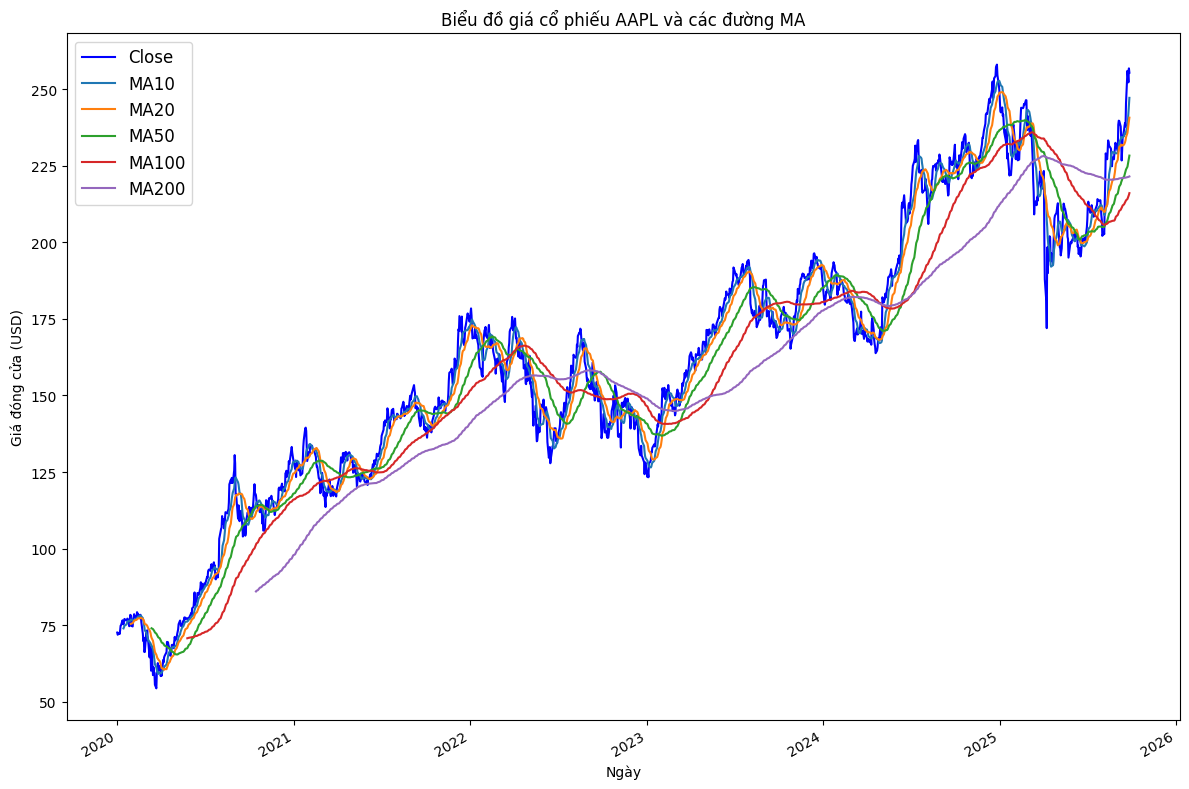

In [29]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Lấy dữ liệu cổ phiếu AAPL từ 2020 đến nay
df = yf.download("AAPL", start="2020-01-01")

# Làm sạch dữ liệu
df = df.dropna()
df = df[df['Close'] != 0]

# Tính các đường trung bình động
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA100'] = df['Close'].rolling(window=100).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

# Vẽ biểu đồ giá đóng cửa và các đường MA
plt.figure(figsize=(12, 8))
plt.plot(df['Close'], label='Close', color='blue')
plt.plot(df['MA10'], label='MA10')
plt.plot(df['MA20'], label='MA20')
plt.plot(df['MA50'], label='MA50')
plt.plot(df['MA100'], label='MA100')
plt.plot(df['MA200'], label='MA200')

# Thiết lập nhãn và tiêu đề
plt.title('Biểu đồ giá cổ phiếu AAPL và các đường MA')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa (USD)')
plt.legend(loc='upper left', fontsize=12)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.savefig('AAPL_plot.png', dpi=300)
plt.show()


In [ ]:
## Kết thúc